In [1]:
from TetriumColor.Observer import Observer, Cone
from TetriumColor.Measurement.TetriumMeasurementRoutines import load_primaries_from_csv
import matplotlib.pyplot as plt

In [19]:
primaries = load_primaries_from_csv("../../measurements/2026-02-11/primaries/", primary_order='BGOR') # RGO only
observer = Observer([Cone.m_cone(), Cone.l_cone()])

/Users/jessicalee/miniconda3/envs/tetriumcolor/lib/python3.11/site-packages/colour/utilities/verbose.py:322: ColourUsageWarning: "standalone" argument has been renamed to "show".
  warn(*args, **kwargs)  # noqa: B028
/Users/jessicalee/miniconda3/envs/tetriumcolor/lib/python3.11/site-packages/colour/utilities/verbose.py:322: ColourUsageWarning: "standalone" argument has been renamed to "show".
  warn(*args, **kwargs)  # noqa: B028


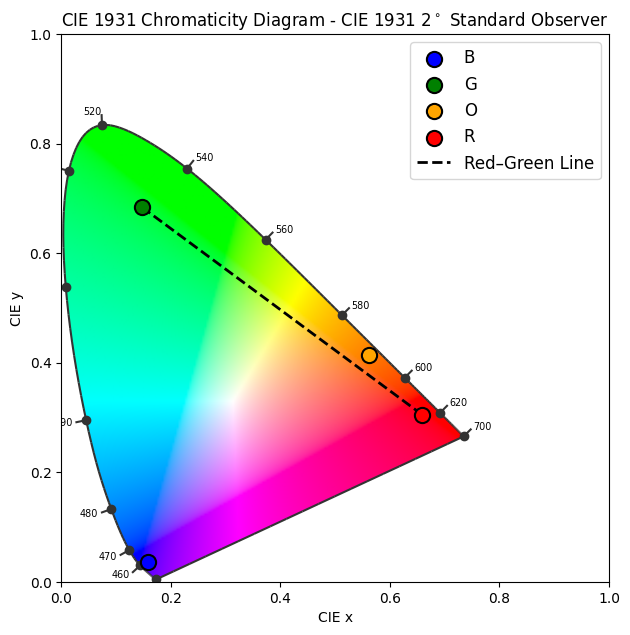

In [20]:
import colour
import colour.plotting
import numpy as np

xy_coords = []
for p in primaries:
    sd = colour.SpectralDistribution(dict(zip(p.wavelengths, p.data)))
    XYZ = colour.sd_to_XYZ(sd)
    xy = colour.XYZ_to_xy(XYZ)
    xy_coords.append(xy)
xy_coords = np.array(xy_coords)

fig, ax = colour.plotting.plot_chromaticity_diagram_CIE1931(standalone=False)
colors = ['blue', 'green', 'orange', 'red']
labels = ['B', 'G', 'O', 'R']
for xy, c, l in zip(xy_coords, colors, labels):
    ax.scatter(xy[0], xy[1], c=c, s=120, zorder=5, label=l, edgecolors='black', linewidths=1.5)

# Draw a line from Red to Green
# Find indices for red and green (assume 'R' is red, 'G' is green, as in the plotting order)
idx_red = labels.index('R')
idx_green = labels.index('G')
xy_red = xy_coords[idx_red]
xy_green = xy_coords[idx_green]
ax.plot([xy_red[0], xy_green[0]], [xy_red[1], xy_green[1]], color='black', linewidth=2, linestyle='--', label='Red–Green Line')

ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
prim_to_cones = observer.observe_spectras(primaries[1:])

In [12]:
desaturating_amount = 0.2
r, g = 0.6, 0.4
rg_vec = (r*prim_to_cones[0] + g*prim_to_cones[2]) * desaturating_amount
field_1 = lambda t: prim_to_cones[0]*t*(1/4) + (1-t)*prim_to_cones[2] * (1/2) # green and red
field_2 = lambda s: s*prim_to_cones[1] + rg_vec  # orange only

Best desaturating_amount: 0.0000 (err=3.4924e-21), t=0.2433, s=0.3317, r/(r+g)=0.8615
NOTE: t is the anomaloscope test field mixing parameter (t=0 is pure red, t=1 is pure green), but the physical r/(r+g) ratio is also shown.


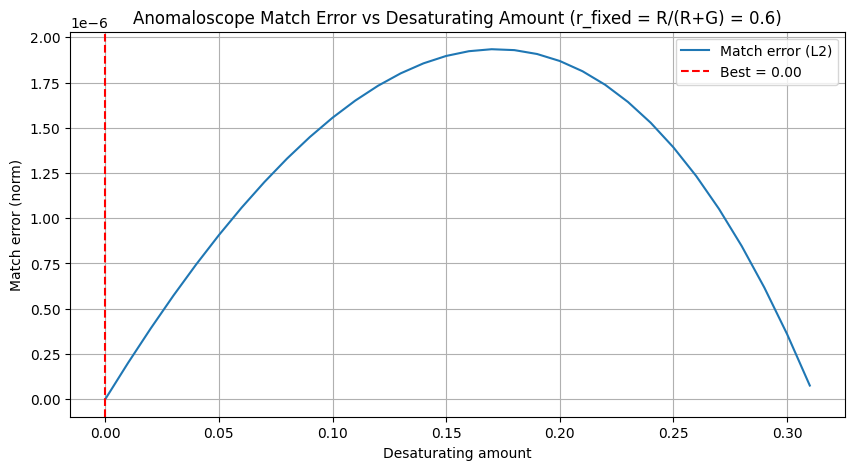

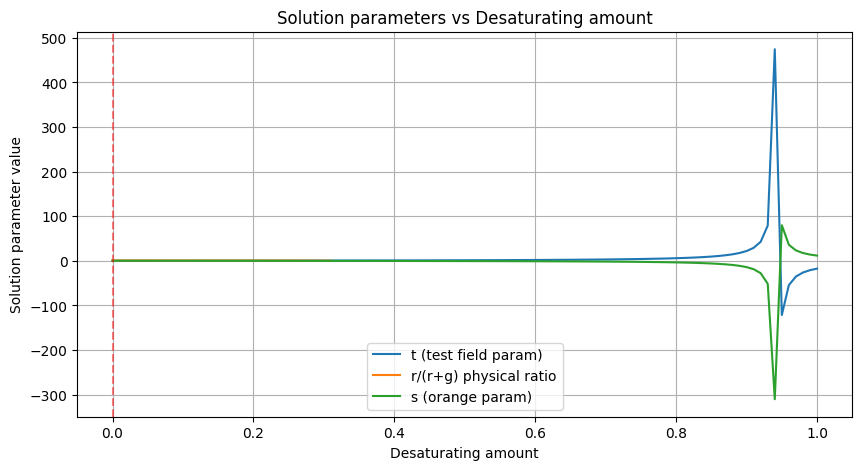

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# We'll keep r fixed (R/G ratio for physical mixture, not for t, which is anomaloscope test value)
r_fixed = 0.6
g_fixed = 1 - r_fixed
orange = prim_to_cones[1]

def solve_match(r=0.6, desaturating_amount=0.0):
    """
    Solve for t (test field mixing parameter, range [0,1], where
     t=0 is pure red, t=1 is pure green)
    and s (scaling for orange side), such that:
      field_1(t) == field_2(s)
    - field_1(t): (1-t)·red + t·green (actually, special weighted version)
    - field_2(s): s*orange + desaturated R/G blend
    Returns error/norm and the optimal t, s, and t_as_rg_ratio.
    t_as_rg_ratio is the physical R/(R+G) ratio if one were to interpret t between 0 and 1.
    """
    g = 1 - r
    rg_vec = (r*prim_to_cones[0] + g*prim_to_cones[2]) * desaturating_amount

    def field_1(t):
        # t is the mixing parameter (0=red, 1=green)
        return prim_to_cones[0]*t*(1/4) + (1-t)*prim_to_cones[2]*(1/2)
    def field_2(s):
        return s*orange + rg_vec

    # Setup system
    A = np.column_stack([
        prim_to_cones[0]*(1/4) - prim_to_cones[2]*(1/2),   # coeff t
        - (orange - rg_vec)                                # coeff s
    ]) # shape (3,2)
    b = -prim_to_cones[2]*(1/2) + rg_vec  # move constants over

    ts_sol, resid, rank, svals = np.linalg.lstsq(A, b, rcond=None)
    t_opt, s_opt = ts_sol
    t, s = t_opt, s_opt

    # Only return error if BOTH t,s are in [0,1]
    if 0 <= t <= 1 and 0 <= s <= 1:
        match_err = np.linalg.norm(field_1(t) - field_2(s))
        # Compute the r/g ratio corresponding to t, based on how the test field is defined:
        # In the anomaloscope, t parametrizes a *weighted* mixture Red/Green. The weights are (R: 1/2) and (G: 1/4)
        # RG physical ratio = (proportion of red) / (proportion of red + green)
        red_part = (1-t) * (1/2)
        green_part = t * (1/4)
        if (red_part + green_part) > 0:
            rg_ratio = red_part / (red_part + green_part)
        else:
            rg_ratio = np.nan  # avoid divide by zero
    else:
        match_err = np.inf
        rg_ratio = np.nan

    return match_err, t, s, rg_ratio

# Scan over a range of desaturating_amount values
desats = np.linspace(0, 1, 101)
errs, t_list, s_list, rg_ratio_list = [], [], [], []

for d in desats:
    err, t, s, rg_ratio = solve_match(r_fixed, desaturating_amount=d)
    errs.append(err)
    t_list.append(t)
    s_list.append(s)
    rg_ratio_list.append(rg_ratio)

errs = np.array(errs)
t_list = np.array(t_list)
s_list = np.array(s_list)
rg_ratio_list = np.array(rg_ratio_list)

# Find minimum error where both t and s are within [0,1]
min_idx = np.argmin(errs)
best_desat = desats[min_idx]
best_err = errs[min_idx]
best_t = t_list[min_idx]
best_s = s_list[min_idx]
best_rg_ratio = rg_ratio_list[min_idx]

print(
    f"Best desaturating_amount: {best_desat:.4f} (err={best_err:.4e}), "
    f"t={best_t:.4f}, s={best_s:.4f}, r/(r+g)={best_rg_ratio:.4f}"
)
print(
    "NOTE: t is the anomaloscope test field mixing parameter "
    "(t=0 is pure red, t=1 is pure green), "
    "but the physical r/(r+g) ratio is also shown."
)

# Plotting
plt.figure(figsize=(10,5))
plt.plot(desats, errs, label="Match error (L2)")
plt.axvline(best_desat, color='r', linestyle='--', label=f"Best = {best_desat:.2f}")
plt.xlabel("Desaturating amount")
plt.ylabel("Match error (norm)")
plt.title(f"Anomaloscope Match Error vs Desaturating Amount (r_fixed = R/(R+G) = {r_fixed})")
plt.legend()
plt.grid(True)
plt.show()

# Optional: plot t, s, and r/(r+g) for reference
plt.figure(figsize=(10,5))
plt.plot(desats, t_list, label='t (test field param)')
plt.plot(desats, rg_ratio_list, label='r/(r+g) physical ratio')
plt.plot(desats, s_list, label='s (orange param)')
plt.xlabel("Desaturating amount")
plt.ylabel("Solution parameter value")
plt.title("Solution parameters vs Desaturating amount")
plt.axvline(best_desat, color='r', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True)
plt.show()